# Laboratorio 2 - catch22 


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import pycatch22
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option("display.max_columns", None)

## Cargar datos y reconstruir las series del laboratorio anterior

Se reconstruyen exactamente las mismas series de los notebooks del lab paasado: `serie_obligatoria_total_mensual`,
`serie_pais_residencia` y `serie_viasde_ingreso`: la serie total, los 3 países con más viajeros
y las 3 vías de ingreso.

In [2]:
ARCHIVO = Path("Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx")
if not ARCHIVO.exists():
    raise FileNotFoundError(f"No está el archivo: {ARCHIVO.resolve()}")

datos = pd.read_excel(ARCHIVO)

datos["Año"] = pd.to_numeric(datos["Año"], errors="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors="coerce")
datos["Viajero"] = pd.to_numeric(datos["Viajero"], errors="coerce")
datos["Fecha"] = pd.to_datetime(
    {"year": datos["Año"], "month": datos["Mes cod"], "day": 1}, errors="coerce"
)

TIPOS_SELECCIONADOS = ["Turista", "Excursionista"]
datos_visitantes = datos[datos["Tipo de Viajero"].isin(TIPOS_SELECCIONADOS)].copy()

print("dataset:", datos.shape)

dataset: (161036, 14)


In [3]:
# --- serie_total (serie_obligatoria_total_mensual.ipynb) -------------------
serie_total = (
    datos_visitantes
    .dropna(subset=["Fecha", "Viajero"])
    .groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
    .asfreq("MS")
)
serie_total.name = "Total"

# --- series por país (serie_pais_residencia.ipynb) --------------------------
top_3_paises = (
    datos.groupby("País")["Viajero"].sum().nlargest(3).index.tolist()
)

series_paises = {}
for pais in top_3_paises:
    df_pais = datos[datos["País"] == pais]
    serie_mensual = df_pais.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    series_paises[f"Pais_{pais}"] = serie_mensual

# --- series por vía (serie_viasde_ingreso.ipynb) -----------------------------
series_vias = (
    datos_visitantes
    .dropna(subset=["Fecha", "Vía", "Viajero"])
    .groupby(["Fecha", "Vía"])["Viajero"]
    .sum()
    .unstack("Vía")
    .sort_index()
    .asfreq("MS")
)

series_por_via = {
    "Via_Aerea": series_vias["Aérea"],
    "Via_Terrestre": series_vias["Terrestre"],
    "Via_Maritima": series_vias["Marítima"].dropna(),  # tiene huecos históricos
}

# --- diccionario final con TODAS las series del laboratorio anterior --------
todas_las_series = {"Total": serie_total, **series_paises, **series_por_via}

print("Series incluidas en el análisis catch22:")
for nombre, serie in todas_las_series.items():
    print(f"  - {nombre}: {len(serie)} observaciones "
          f"({serie.index.min().date()} a {serie.index.max().date()})")

Series incluidas en el análisis catch22:
  - Total: 210 observaciones (2009-01-01 a 2026-06-01)
  - Pais_El Salvador: 210 observaciones (2009-01-01 a 2026-06-01)
  - Pais_Guatemala: 168 observaciones (2009-01-01 a 2022-12-01)
  - Pais_Estados Unidos de América: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Aerea: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Terrestre: 210 observaciones (2009-01-01 a 2026-06-01)
  - Via_Maritima: 96 observaciones (2009-01-01 a 2016-12-01)


## 2.3 Extracción de las 22 características de catch22 y construcción de la matriz

Cada fila de `matriz_catch22` es una serie temporal, cada columna una característica de catch22.

In [4]:
filas = []
for nombre, serie in todas_las_series.items():
    serie_limpia = serie.dropna().astype(float)
    resultado = pycatch22.catch22_all(serie_limpia.to_list())
    fila = dict(zip(resultado["names"], resultado["values"]))
    fila["serie"] = nombre
    filas.append(fila)

matriz_catch22 = pd.DataFrame(filas).set_index("serie")

print("Matriz catch22 (series x 22 características):", matriz_catch22.shape)
matriz_catch22

Matriz catch22 (series x 22 características): (7, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,0.082725,0.341996,8.965200,3,0.352307,-0.061859,0.933014,30.0,0.013774,11,0.318316,2.0,0.055556,0.209524,0.323810,0.820223,6.0,1.851842,0.833333,0.857143,0.122718,0.625905
Pais_El Salvador,-0.367487,-0.590398,13.873639,3,0.476428,-0.035848,0.904306,50.0,0.020833,3,0.318767,2.0,0.038462,0.728571,0.304762,0.859559,5.0,1.781165,0.857143,0.857143,0.073631,0.530967
Pais_Guatemala,-0.452735,-0.686895,8.500395,10,0.466157,0.000222,0.928144,49.0,0.020833,11,0.333742,9.0,0.052632,0.505952,0.642857,0.848429,6.0,1.728439,0.853659,0.853659,0.122718,0.562307
Pais_Estados Unidos de América,-0.628976,-0.373392,9.224247,2,0.228623,0.012101,0.923445,12.0,0.020833,5,0.280009,1.0,0.038462,0.828571,0.319048,0.723445,5.0,1.973228,0.166667,0.142857,0.098175,0.738999
Via_Aerea,-0.398224,-0.114663,6.590944,10,0.206212,-0.162779,0.956938,34.0,0.010204,11,0.209901,9.0,0.071429,0.185714,0.323810,0.758284,5.0,2.000891,0.857143,0.857143,0.171806,0.738677
Via_Terrestre,0.277301,-0.193022,9.572755,2,0.484160,-0.024702,0.933014,29.0,0.013774,3,0.335739,1.0,0.055556,0.219048,0.328571,0.817693,6.0,1.781787,0.833333,0.857143,0.098175,0.615634
Via_Maritima,-0.466415,-0.466415,1.023727,2,0.093351,-0.436318,1.000000,8.0,0.006187,3,0.077741,1.0,0.500000,-0.020833,0.437500,0.452156,4.0,2.110083,0.171429,0.657143,1.030835,1.101251


### 2.4 Estandarización de las características (necesario antes de PCA/clustering)

In [5]:
escalador = StandardScaler()
matriz_estandarizada = pd.DataFrame(
    escalador.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)

matriz_estandarizada

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
Total,1.187296,1.987207,0.199568,-0.454406,0.157273,0.268722,-0.239672,-0.018985,-0.264219,1.137147,0.577189,-0.454406,-0.384807,-0.584531,-0.519253,0.502659,1.020621,-0.290127,0.587797,0.529063,-0.381246,-0.425054
Pais_El Salvador,-0.289970,-0.909981,1.569457,-0.454406,1.017175,0.445882,-1.248108,1.309956,1.038756,-0.985527,0.582327,-0.454406,-0.493609,1.200349,-0.686609,0.802387,-0.408248,-0.832713,0.665509,0.529063,-0.533745,-0.955615
Pais_Guatemala,-0.569691,-1.209821,0.069846,1.569766,0.946020,0.691558,-0.410764,1.243509,1.038756,1.137147,0.753244,1.569766,-0.403418,0.434816,2.283966,0.717577,1.020621,-1.237491,0.654137,0.515003,-0.381246,-0.780470
Pais_Estados Unidos de América,-1.147986,-0.235689,0.271865,-0.743573,-0.699599,0.772470,-0.575817,-1.215032,1.038756,-0.454859,0.139970,-0.743573,-0.493609,1.544225,-0.561092,-0.234768,-0.408248,0.641756,-1.588146,-2.353266,-0.457496,0.206977
Via_Aerea,-0.390826,0.568251,-0.463060,1.569766,-0.854859,-0.418662,0.600690,0.246803,-0.923165,1.137147,-0.660193,1.569766,-0.283778,-0.666406,-0.519253,0.030694,-0.408248,0.854124,0.665509,0.529063,-0.228748,0.205176
Via_Terrestre,1.825754,0.324767,0.369130,-0.743573,1.070742,0.521798,-0.239672,-0.085432,-0.264219,-0.985527,0.776033,-0.743573,-0.384807,-0.551781,-0.477414,0.483380,1.020621,-0.827936,0.587797,0.529063,-0.457496,-0.482448
Via_Maritima,-0.614577,-0.524733,-2.016806,-0.743573,-1.636751,-2.281768,2.113343,-1.480820,-1.664663,-0.985527,-2.168570,-0.743573,2.444028,-1.376674,0.479655,-2.301929,-1.837117,1.692387,-1.572603,-0.277989,2.439977,2.231435


## PCA y clustering


In [6]:
pca = PCA()
componentes = pca.fit_transform(matriz_estandarizada)
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por componente:")
for i, (v, va) in enumerate(zip(varianza_explicada, varianza_acumulada), start=1):
    print(f"  PC{i}: {v:.3f}  (acumulada: {va:.3f})")

componentes_df = pd.DataFrame(
    componentes,
    index=matriz_estandarizada.index,
    columns=[f"PC{i+1}" for i in range(componentes.shape[1])],
)
componentes_df

Varianza explicada por componente:
  PC1: 0.544  (acumulada: 0.544)
  PC2: 0.179  (acumulada: 0.723)
  PC3: 0.141  (acumulada: 0.864)
  PC4: 0.080  (acumulada: 0.944)
  PC5: 0.044  (acumulada: 0.988)
  PC6: 0.012  (acumulada: 1.000)
  PC7: 0.000  (acumulada: 1.000)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
serie,,,,,,,
Total,-1.352574,0.775584,2.443197,1.156792,0.560160,0.836325,4.127544e-16
Pais_El Salvador,-2.908343,-1.614837,-0.383945,-1.484456,-1.644464,0.379720,4.127544e-16
Pais_Guatemala,-3.040647,2.098136,-2.683135,-0.791964,1.172429,0.065804,4.127544e-16
Pais_Estados Unidos de América,0.475197,-3.680058,-1.370524,1.630261,0.555832,-0.167126,4.127544e-16
Via_Aerea,0.785749,2.505570,-0.428465,1.718775,-1.343347,-0.445408,4.127544e-16
Via_Terrestre,-1.733244,-0.333257,2.505246,-1.056595,0.537032,-0.848649,4.127544e-16
Via_Maritima,7.773862,0.248861,-0.082375,-1.172814,0.162358,0.179334,4.127544e-16


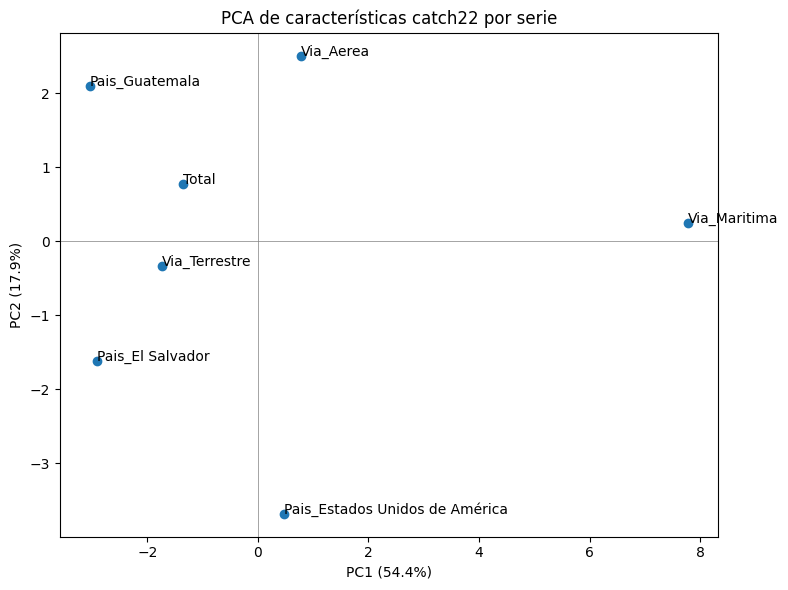

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(componentes_df["PC1"], componentes_df["PC2"])
for nombre, fila in componentes_df.iterrows():
    plt.annotate(nombre, (fila["PC1"], fila["PC2"]))
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlabel(f"PC1 ({varianza_explicada[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({varianza_explicada[1]*100:.1f}%)")
plt.title("PCA de características catch22 por serie")
plt.tight_layout()
plt.show()

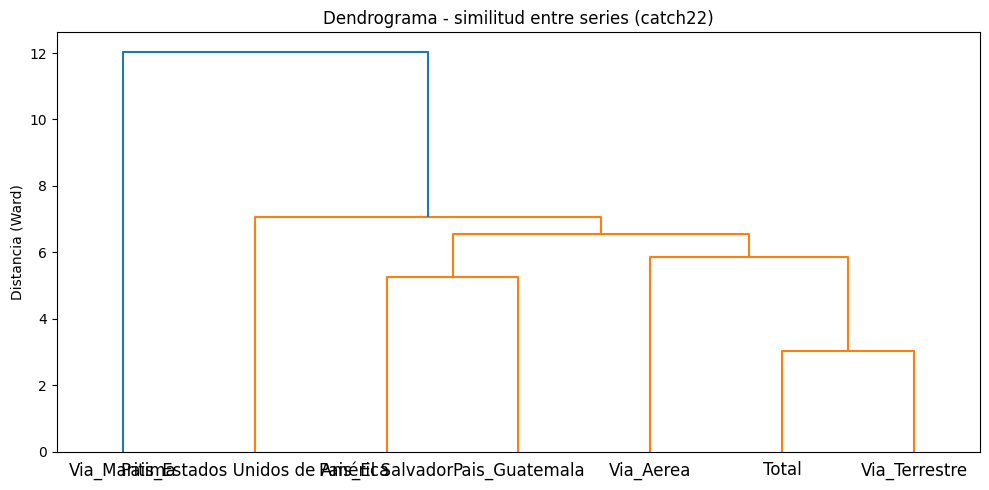

In [8]:
enlace = linkage(matriz_estandarizada, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(enlace, labels=matriz_estandarizada.index.tolist())
plt.title("Dendrograma - similitud entre series (catch22)")
plt.ylabel("Distancia (Ward)")
plt.tight_layout()
plt.show()

In [ ]:
# Número de clusters: se prueba con silhouette 
n_series = matriz_estandarizada.shape[0]
mejores_k, mejor_score = None, -1
for k in range(2, n_series):
    etiquetas_k = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(
        matriz_estandarizada
    )
    score = silhouette_score(matriz_estandarizada, etiquetas_k)
    print(f"k={k} -> silhouette={score:.3f}")
    if score > mejor_score:
        mejor_score, mejores_k = score, k

print(f"\nMejor número de clusters según silhouette: k={mejores_k} (score={mejor_score:.3f})")

clustering_final = AgglomerativeClustering(n_clusters=mejores_k, linkage="ward")
etiquetas = clustering_final.fit_predict(matriz_estandarizada)

resultado_clusters = pd.DataFrame({
    "serie": matriz_estandarizada.index,
    "cluster": etiquetas,
}).sort_values("cluster")

resultado_clusters

k=2 -> silhouette=0.358
k=3 -> silhouette=0.126
k=4 -> silhouette=0.102
k=5 -> silhouette=0.106
k=6 -> silhouette=0.090

Mejor número de clusters según silhouette: k=2 (score=0.358)


,serie,cluster
0,Total,0
1,Pais_El Salvador,0
2,Pais_Guatemala,0
3,Pais_Estados Unidos de América,0
4,Via_Aerea,0
5,Via_Terrestre,0
6,Via_Maritima,1


## 2.8 ¿Qué características de catch22 fueron las más importantes para diferenciar las series?

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=matriz_estandarizada.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
)

# componentes que explican el 90% de la varianza
n_componentes_90 = int(np.argmax(varianza_acumulada >= 0.90)) + 1
pesos = varianza_explicada[:n_componentes_90]

importancia = (
    loadings.iloc[:, :n_componentes_90].abs().values * pesos
).sum(axis=1)

importancia_features = (
    pd.Series(importancia, index=loadings.index)
    .sort_values(ascending=False)
)

print(f"Usando los primeros {n_componentes_90} componentes "
      f"({varianza_acumulada[n_componentes_90-1]*100:.1f}% de varianza acumulada):")
importancia_features

Usando los primeros 4 componentes (94.4% de varianza acumulada):


SB_TransitionMatrix_3ac_sumdiagcov             0.197520
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.193770
SB_BinaryStats_mean_longstretch1               0.192470
DN_OutlierInclude_p_001_mdrmd                  0.191373
CO_trev_1_num                                  0.185595
MD_hrv_classic_pnn40                           0.184592
CO_f1ecac                                      0.180287
SP_Summaries_welch_rect_centroid               0.178034
CO_HistogramAMI_even_2_5                       0.177018
SB_BinaryStats_diff_longstretch0               0.176481
FC_LocalSimple_mean1_tauresrat                 0.175757
SB_MotifThree_quantile_hh                      0.175055
CO_Embed2_Dist_tau_d_expfit_meandiff           0.173395
SP_Summaries_welch_rect_area_5_1               0.170176
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1         0.167360
CO_FirstMin_ac                                 0.165634
IN_AutoMutualInfoStats_40_gaussian_fmmi        0.165634
FC_LocalSimple_mean3_stderr                    0

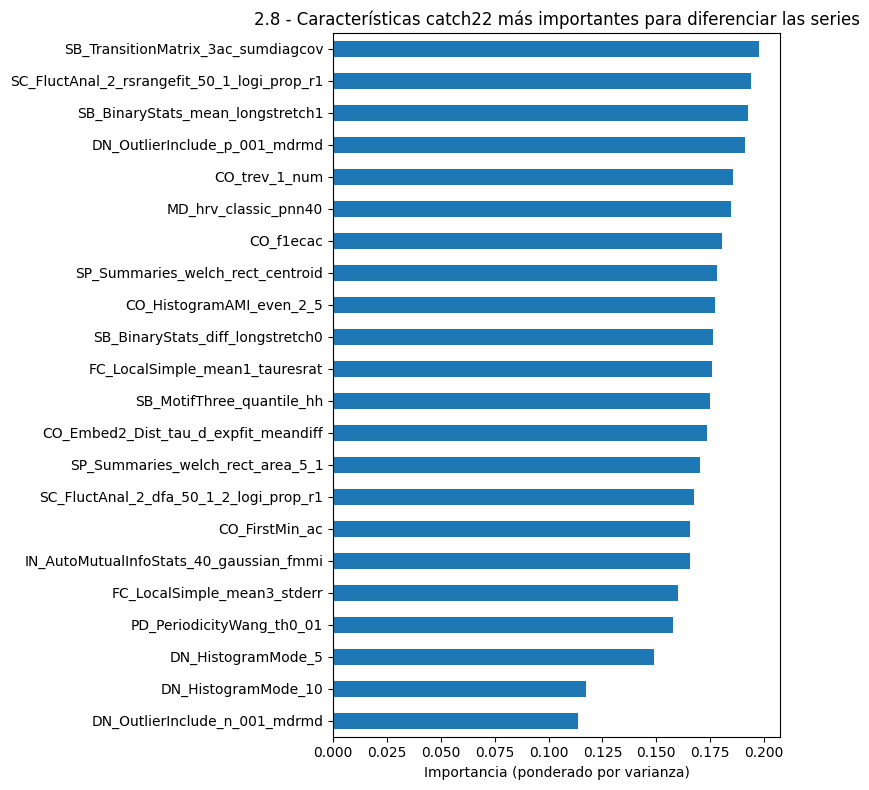

In [14]:
plt.figure(figsize=(8, 8))
importancia_features.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (ponderado por varianza)")
plt.title("2.8 - Características catch22 más importantes para diferenciar las series")
plt.tight_layout()
plt.show()

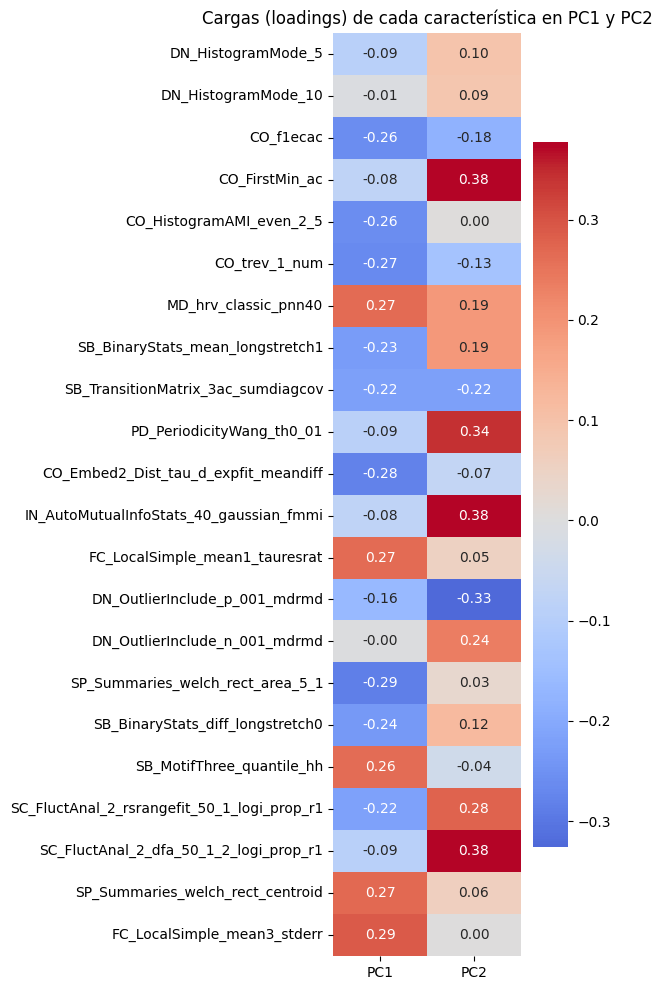

In [12]:
plt.figure(figsize=(6, 10))
sns.heatmap(loadings.iloc[:, :2], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cargas (loadings) de cada característica en PC1 y PC2")
plt.tight_layout()
plt.show()

## 2.9 ¿Existen grupos naturales de series? ¿Qué tienen en común?


In [13]:
categoria_original = {}
for nombre in todas_las_series:
    if nombre == "Total":
        categoria_original[nombre] = "Total"
    elif nombre.startswith("Pais_"):
        categoria_original[nombre] = "País"
    elif nombre.startswith("Via_"):
        categoria_original[nombre] = "Vía de ingreso"

resultado_clusters["categoria_original"] = resultado_clusters["serie"].map(categoria_original)

print("Grupos naturales encontrados:")
for cluster_id, grupo in resultado_clusters.groupby("cluster"):
    print(f"\nCluster {cluster_id}:")
    print(grupo[["serie", "categoria_original"]].to_string(index=False))

    series_del_cluster = grupo["serie"].tolist()
    top_features = importancia_features.head(5).index.tolist()
    print("  Promedio (estandarizado) de las 5 características más importantes:")
    print(matriz_estandarizada.loc[series_del_cluster, top_features].mean().round(2))

Grupos naturales encontrados:

Cluster 0:
                         serie categoria_original
                         Total              Total
              Pais_El Salvador               País
                Pais_Guatemala               País
Pais_Estados Unidos de América               País
                     Via_Aerea     Vía de ingreso
                 Via_Terrestre     Vía de ingreso
  Promedio (estandarizado) de las 5 características más importantes:
SB_TransitionMatrix_3ac_sumdiagcov             0.28
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.26
SB_BinaryStats_mean_longstretch1               0.25
DN_OutlierInclude_p_001_mdrmd                  0.23
CO_trev_1_num                                  0.38
dtype: float64

Cluster 1:
       serie categoria_original
Via_Maritima     Vía de ingreso
  Promedio (estandarizado) de las 5 características más importantes:
SB_TransitionMatrix_3ac_sumdiagcov            -1.66
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1   -1.57
SB_BinaryStats_